In [1]:
import pandas as pd

# Load train dataset
df = pd.read_csv("/Users/delphina/Downloads/YEAR 02/DSGP/CSV files /Hotel-A-test.csv")



In [2]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [3]:
# Check missing values
print(df.isnull().sum())


reservation-id            0
gender                    0
age                       0
ethnicity                 0
educational_level         0
income                    0
country_region            0
hotel_type                0
expected_checkin          0
expected_checkout         0
booking_date              0
adults                    0
children                  0
babies                    0
meal_type                 0
visted_previously         0
previous_cancellations    0
deposit_type              0
booking_channel           0
required_car_parking      0
use_promotion             0
discount_rate             0
room_rate                 0
dtype: int64


In [4]:
df.describe()

,reservation-id,age,adults,children,babies,discount_rate,room_rate
count,4.318000e+03,4318.000000,4318.000000,4318.000000,4318.000000,4318.000000,4318.000000
mean,5.042908e+07,43.788328,2.369847,1.730199,0.345762,12.416628,175.572024
std,2.879425e+07,15.257078,1.191075,0.721406,0.566368,11.266842,42.941781
min,6.831800e+04,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000
25%,2.547685e+07,31.000000,2.000000,1.000000,0.000000,5.000000,139.000000
50%,5.112349e+07,44.000000,2.000000,2.000000,0.000000,10.000000,176.000000
75%,7.515864e+07,57.000000,3.000000,2.000000,1.000000,20.000000,212.000000
max,9.998367e+07,70.000000,5.000000,3.000000,2.000000,40.000000,250.000000


In [5]:
# Fill missing values
df['children'] = df['children'].fillna(0)
df['babies'] = df['babies'].fillna(0)
df['age'] = df['age'].fillna(df['age'].median())

In [6]:
# Remove duplicates
df = df.drop_duplicates()


In [7]:
# Convert date columns to datetime
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['expected_checkin'] = pd.to_datetime(df['expected_checkin'])
df['expected_checkout'] = pd.to_datetime(df['expected_checkout'])

In [8]:
# Fix categorical text (clean spaces/case)
cat_cols = ['gender','hotel_type','meal_type','deposit_type','booking_channel']
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

In [9]:
#lead time 

df['lead_time'] = (df['expected_checkin'] - df['booking_date']).dt.days

In [10]:
#Length of Stay
df['length_of_stay'] = (df['expected_checkout'] - df['expected_checkin']).dt.days

In [11]:
df['lead_time_flag'] = df['lead_time'].apply(lambda x: 'negative' if x < 0 else 'valid')

In [12]:
df[['booking_date','expected_checkin','lead_time','length_of_stay']].head(10)


,booking_date,expected_checkin,lead_time,length_of_stay
0,2016-10-28,2016-11-18,21,1
1,2016-08-06,2016-11-18,104,1
2,2017-04-08,2017-04-28,20,3
3,2016-05-20,2016-11-18,182,2
4,2016-10-31,2016-11-18,18,2
5,2016-07-28,2016-11-18,113,1
6,2016-07-17,2016-11-18,124,2
7,2016-08-01,2016-11-18,109,2
8,2016-06-10,2016-11-18,161,1
9,2016-04-15,2016-11-18,217,4


In [13]:
print(df['lead_time'].min())
print((df['lead_time'] < 0).sum())

-4
27


In [14]:
df.to_csv("/Users/delphina/Downloads/YEAR 02/DSGP/CSV files /Hotel-A-test-cleaned.csv", index=False)

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("//Users/delphina/Downloads/YEAR 02/DSGP/CSV files /Hotel-A-test-cleaned.csv")

/var/folders/9k/cclqqmtj5vq95l2lj6r30tj80000gn/T/ipykernel_33362/2524709004.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hotel_type', data=df, ax=axes[0], palette='pastel').set_title('Hotel Type')
/var/folders/9k/cclqqmtj5vq95l2lj6r30tj80000gn/T/ipykernel_33362/2524709004.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='deposit_type', data=df, ax=axes[1], palette='pastel').set_title('Deposit Type')
/var/folders/9k/cclqqmtj5vq95l2lj6r30tj80000gn/T/ipykernel_33362/2524709004.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.count

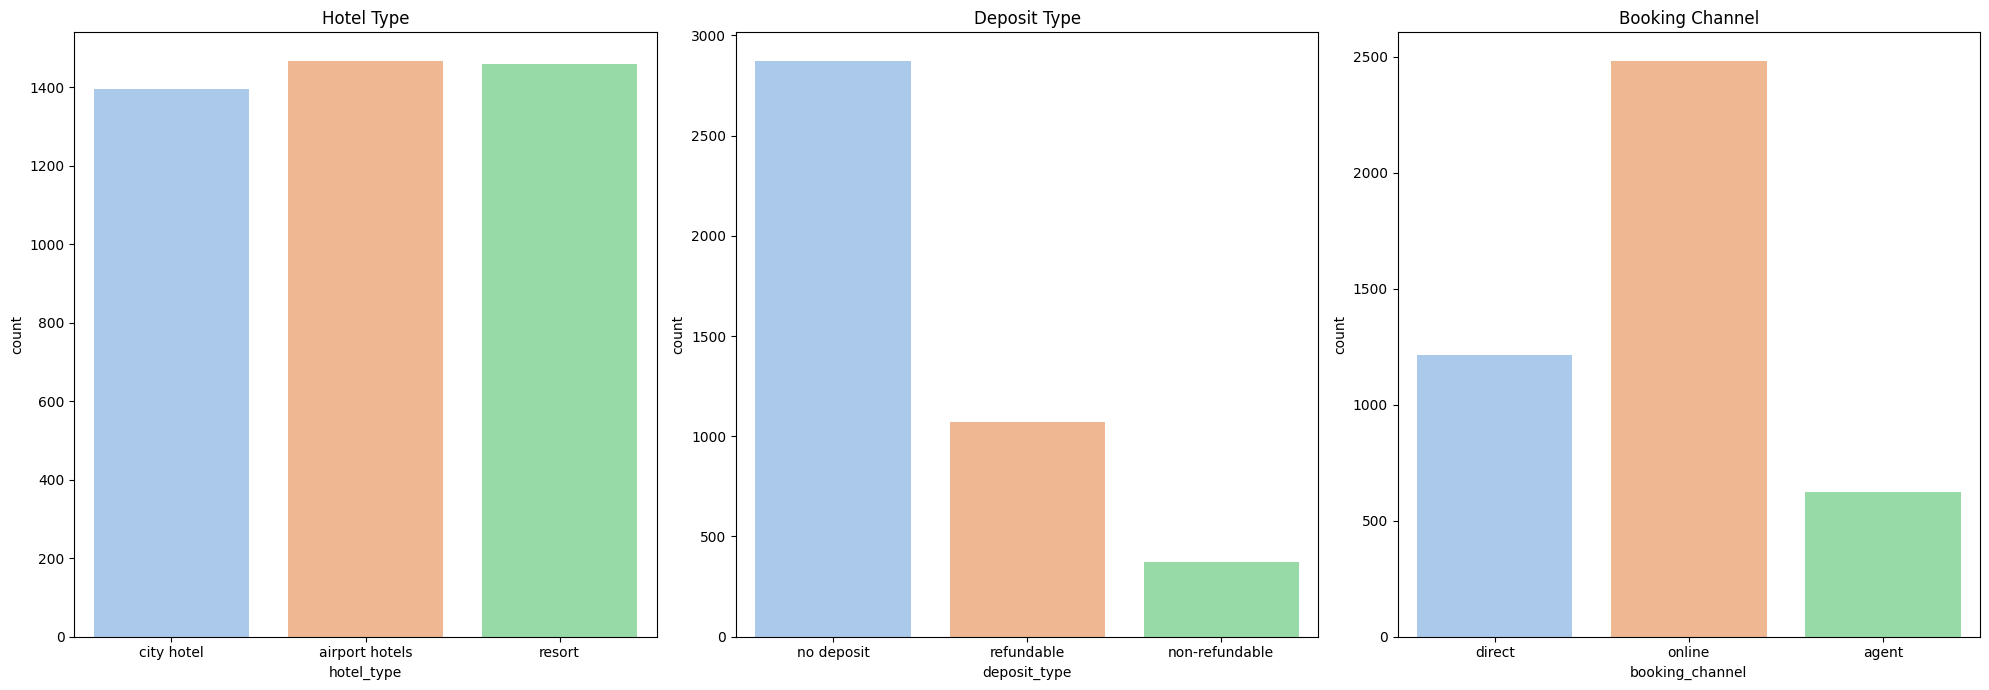

In [17]:
# Categorical Features: Hotel_Type, Deposit_type, Booking_channel
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.countplot(x='hotel_type', data=df, ax=axes[0], palette='pastel').set_title('Hotel Type')
sns.countplot(x='deposit_type', data=df, ax=axes[1], palette='pastel').set_title('Deposit Type')
sns.countplot(x='booking_channel', data=df, ax=axes[2], palette='pastel').set_title('Booking Channel')
plt.tight_layout()

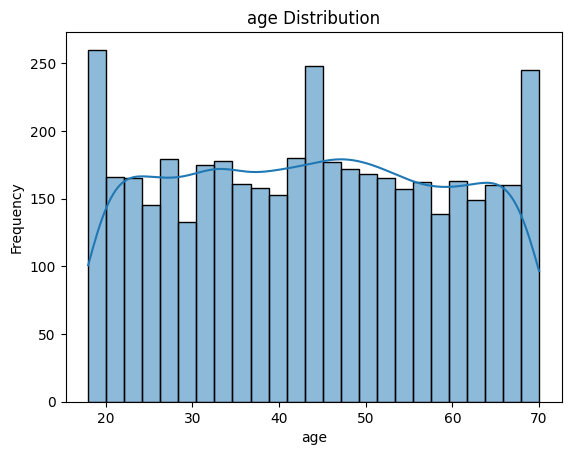

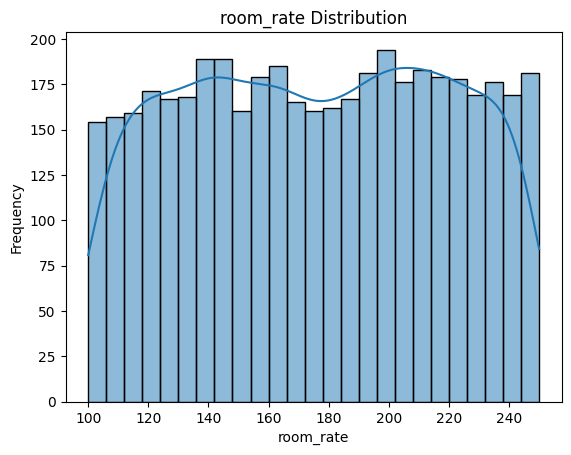

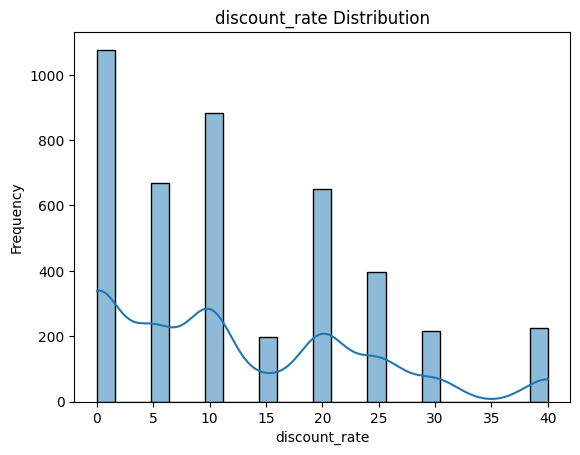

In [18]:
num_cols = ["age", "room_rate", "discount_rate"]

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], bins=25, kde=True)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

/var/folders/9k/cclqqmtj5vq95l2lj6r30tj80000gn/T/ipykernel_33362/51615142.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat_col, y=num_col, order=order, palette="Set2", ax=axes[i])
/var/folders/9k/cclqqmtj5vq95l2lj6r30tj80000gn/T/ipykernel_33362/51615142.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat_col, y=num_col, order=order, palette="Set2", ax=axes[i])
/var/folders/9k/cclqqmtj5vq95l2lj6r30tj80000gn/T/ipykernel_33362/51615142.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat_col, y=

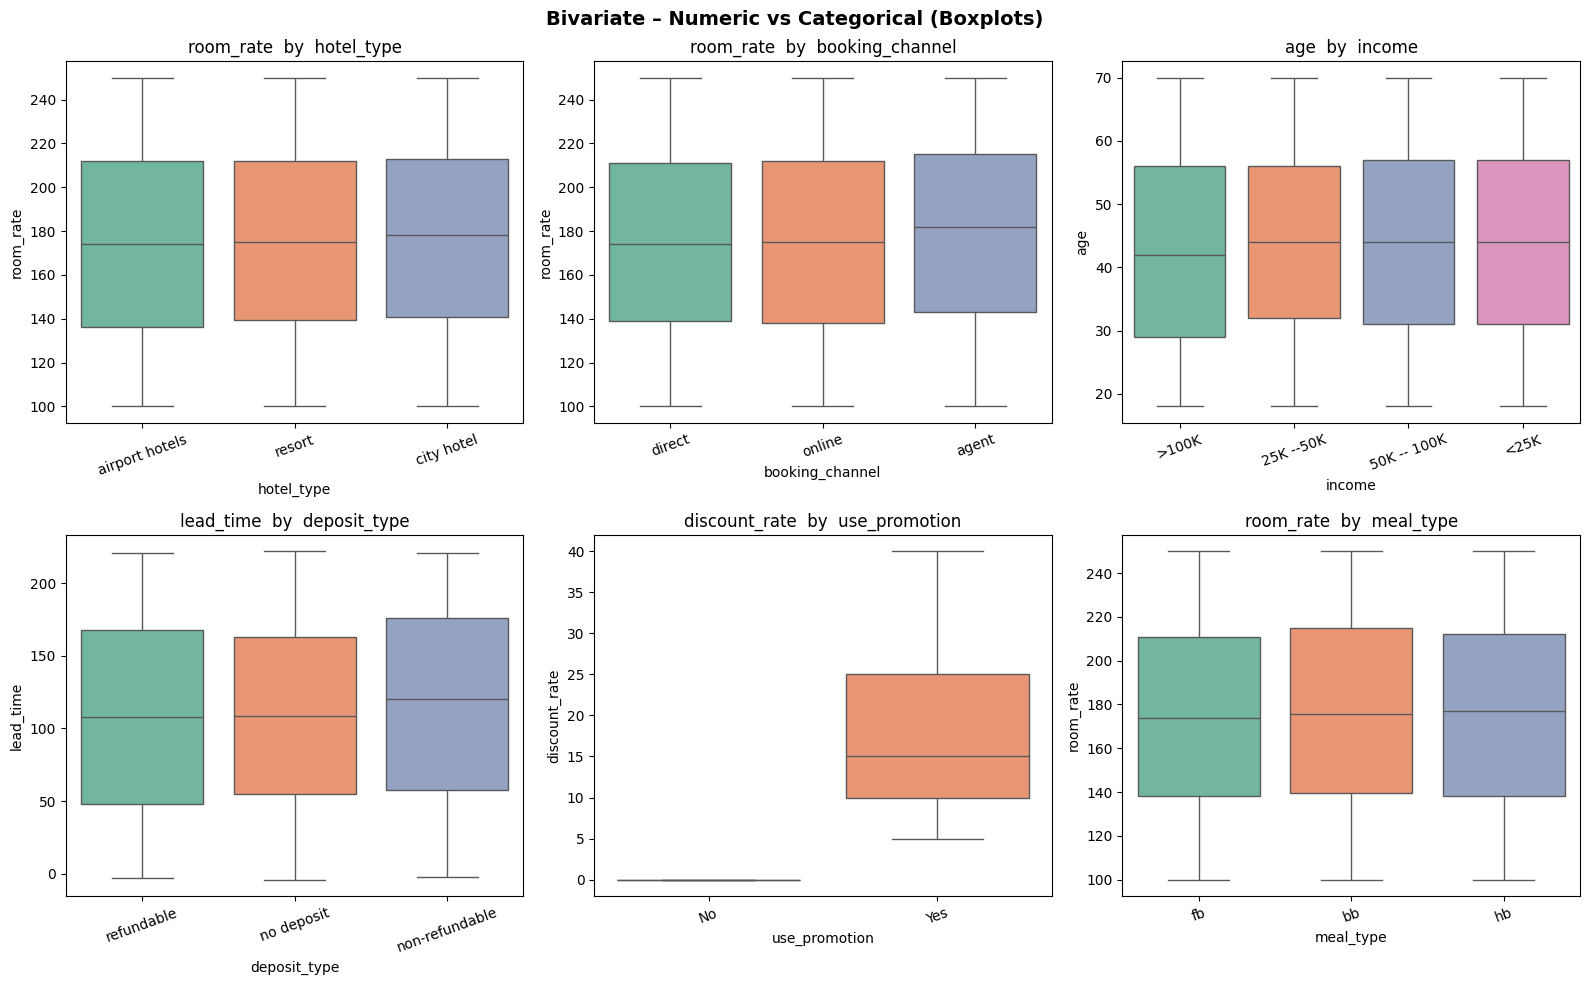

In [19]:
pairs_num_cat = [
    ("room_rate",    "hotel_type"),
    ("room_rate",    "booking_channel"),
    ("age",          "income"),
    ("lead_time",    "deposit_type"),
    ("discount_rate","use_promotion"),
    ("room_rate",    "meal_type"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle("Bivariate – Numeric vs Categorical (Boxplots)", fontsize=14, fontweight="bold")

for i, (num_col, cat_col) in enumerate(pairs_num_cat):
    order = df.groupby(cat_col)[num_col].median().sort_values().index
    sns.boxplot(data=df, x=cat_col, y=num_col, order=order, palette="Set2", ax=axes[i])
    axes[i].set_title(f"{num_col}  by  {cat_col}")
    axes[i].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Multivariate

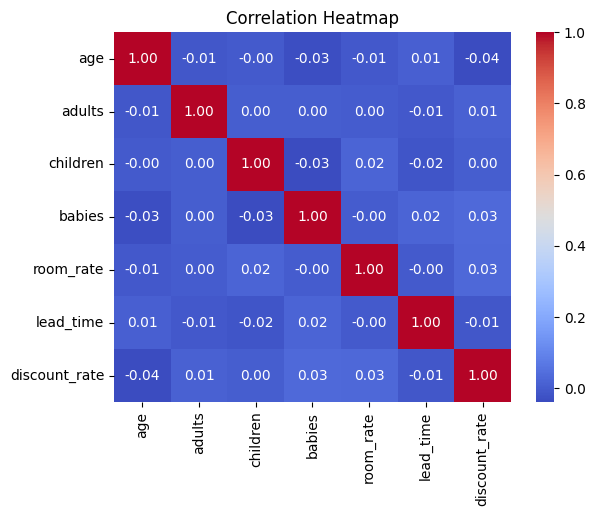

In [20]:
numeric_cols = ["age", "adults", "children", "babies", 
                "room_rate", "lead_time", "discount_rate"]

corr = df[numeric_cols].corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [21]:
df['booking_date'] = pd.to_datetime(df['booking_date'], errors='coerce')

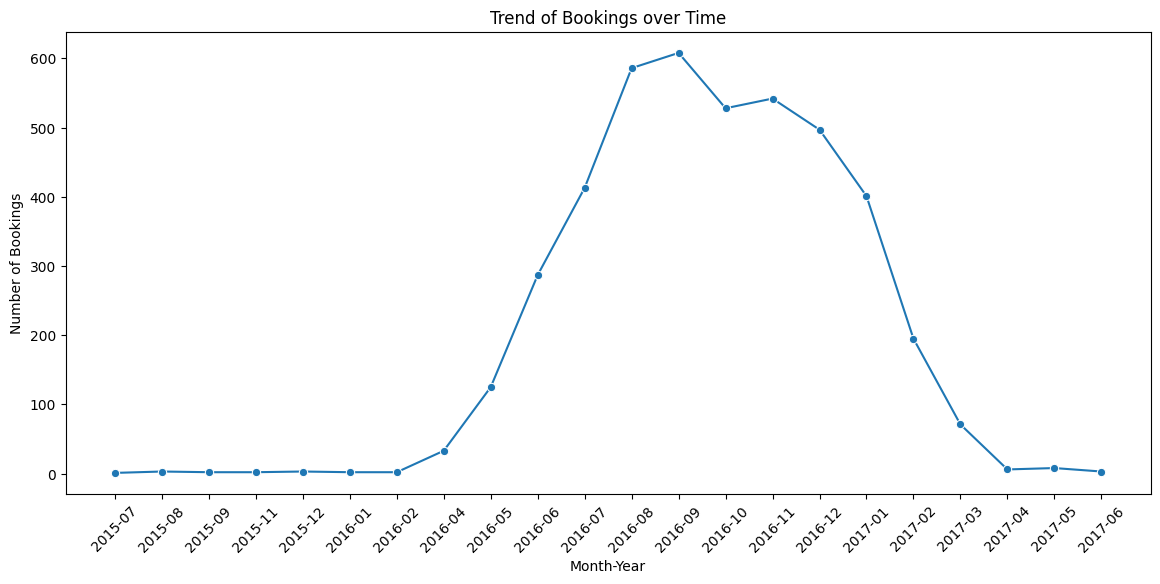

In [22]:
#checking for seasonalities
df['booking_month'] = df['booking_date'].dt.to_period('M').astype(str)
monthly_bookings = df.groupby('booking_month').size().reset_index(name='Count')

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_bookings, x='booking_month', y='Count', marker='o')
plt.xticks(rotation=45)
plt.title('Trend of Bookings over Time')
plt.xlabel('Month-Year')
plt.ylabel('Number of Bookings')
plt.show()

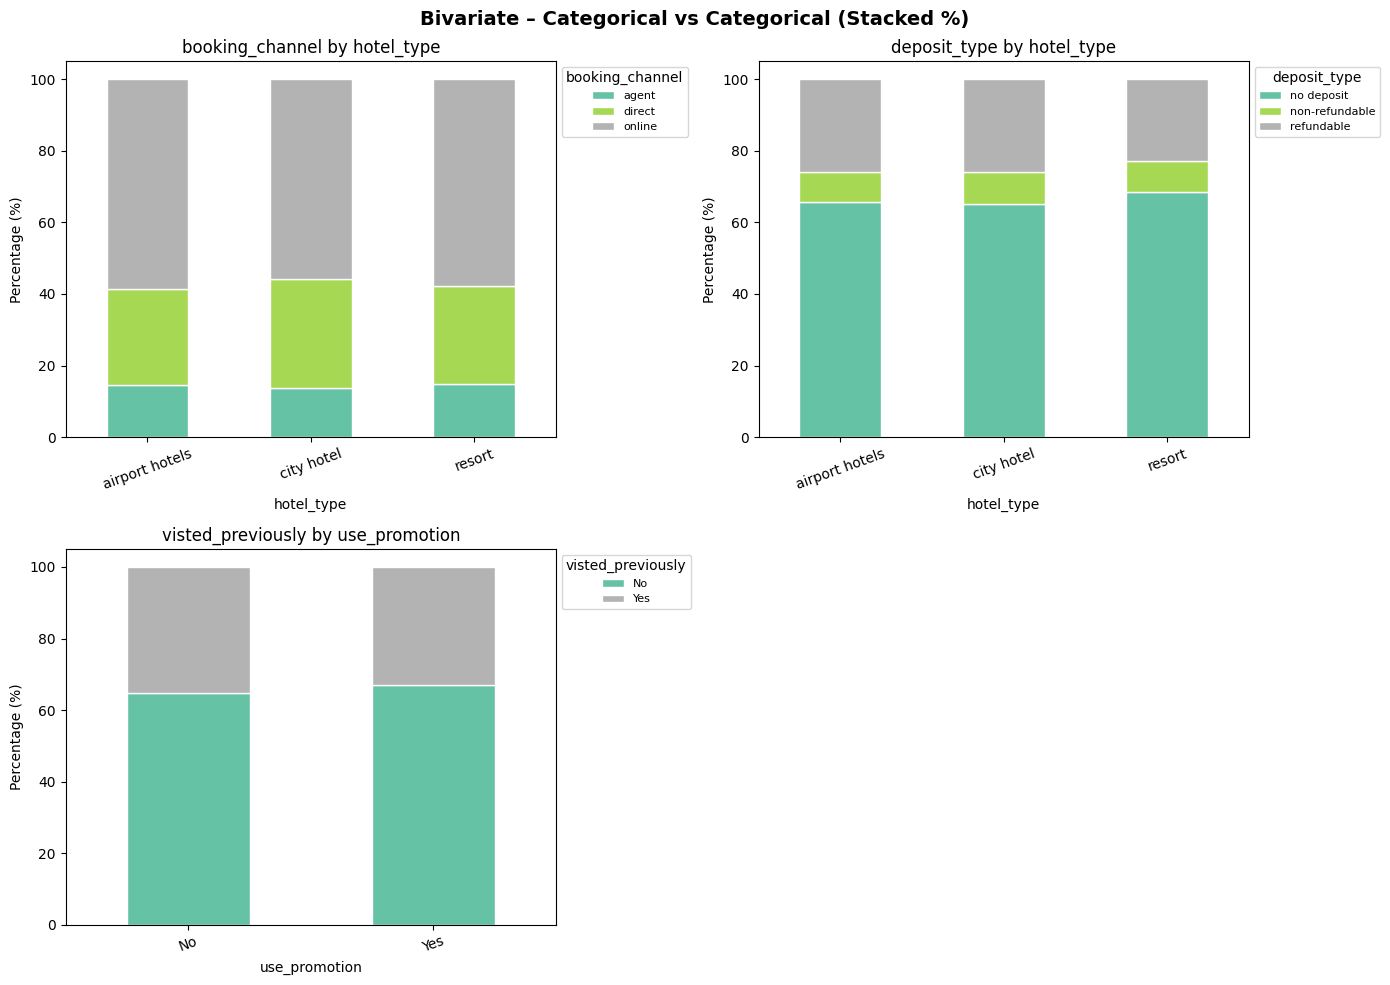

In [ ]:
cat_pairs = [
    ("hotel_type",    "booking_channel"),
    ("hotel_type",    "deposit_type"),
    ("use_promotion", "visted_previously")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
fig.suptitle("Bivariate – Categorical vs Categorical (Stacked %)", fontsize=14, fontweight="bold")
for i, (col1, col2) in enumerate(cat_pairs):
    ct = pd.crosstab(df[col1], df[col2], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=axes[i], colormap="Set2", edgecolor="white")
    axes[i].set_title(f"{col2} by {col1}")
    axes[i].set_ylabel("Percentage (%)")
    axes[i].tick_params(axis="x", rotation=20)
    axes[i].legend(title=col2, bbox_to_anchor=(1, 1), fontsize=8)

#remove last empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

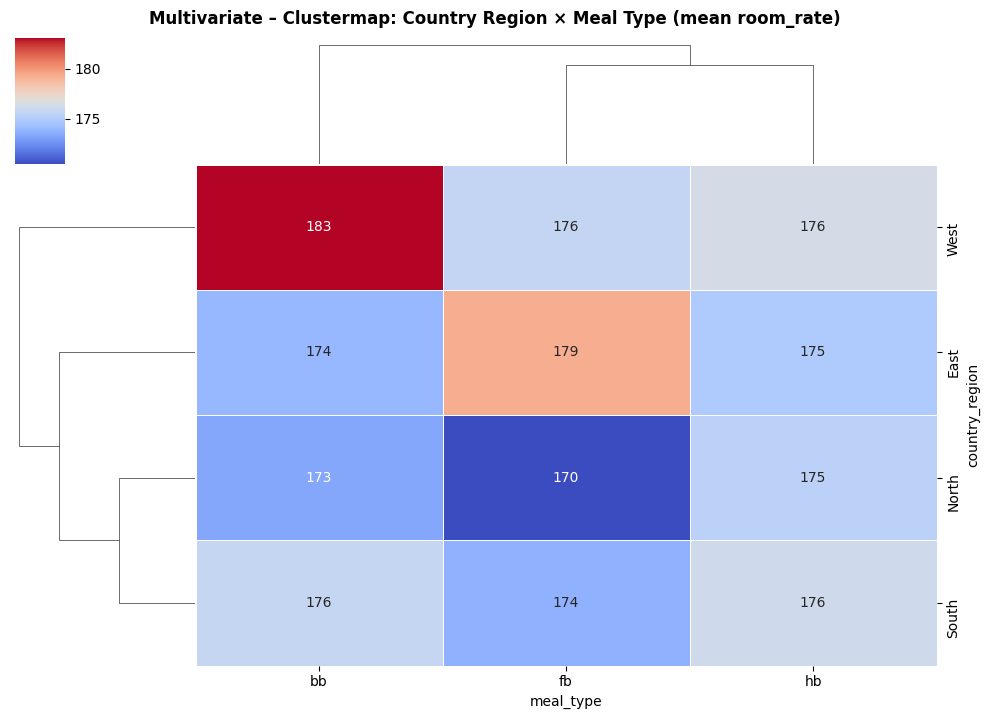

In [24]:
pivot2 = df.pivot_table(values="room_rate", index="country_region",
                        columns="meal_type", aggfunc="mean")

g = sns.clustermap(pivot2, annot=True, fmt=".0f", cmap="coolwarm",
                   figsize=(10, 7), linewidths=0.5)
g.fig.suptitle("Multivariate – Clustermap: Country Region × Meal Type (mean room_rate)",
               y=1.02, fontsize=12, fontweight="bold")
plt.show()

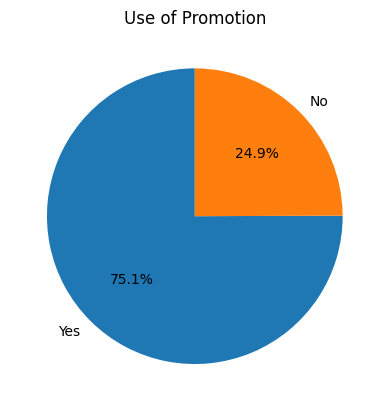

In [25]:
import matplotlib.pyplot as plt

# Get counts
counts = df['use_promotion'].value_counts()

labels = counts.index
sizes = counts.values

plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Use of Promotion')
plt.show()

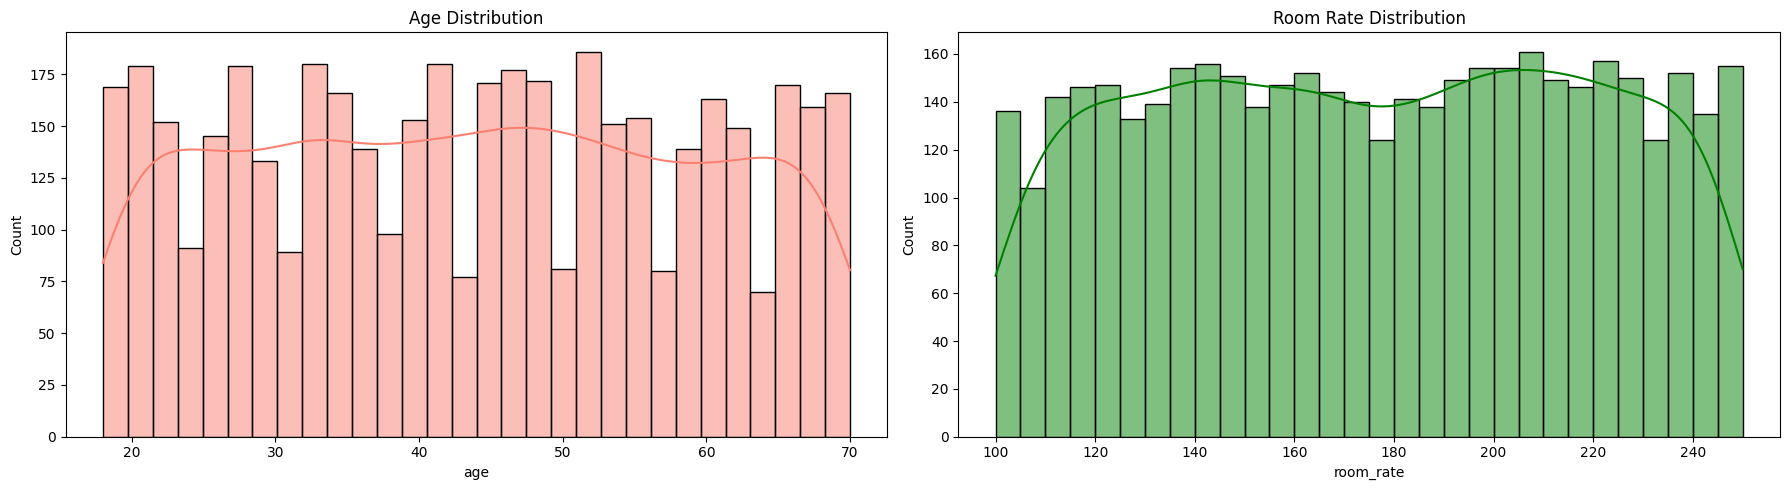

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(df['age'], bins=30, ax=axes[0], kde=True, color='salmon')
axes[0].set_title('Age Distribution')

sns.histplot(df['room_rate'], bins=30, ax=axes[1], kde=True, color='green')
axes[1].set_title('Room Rate Distribution')

plt.tight_layout()

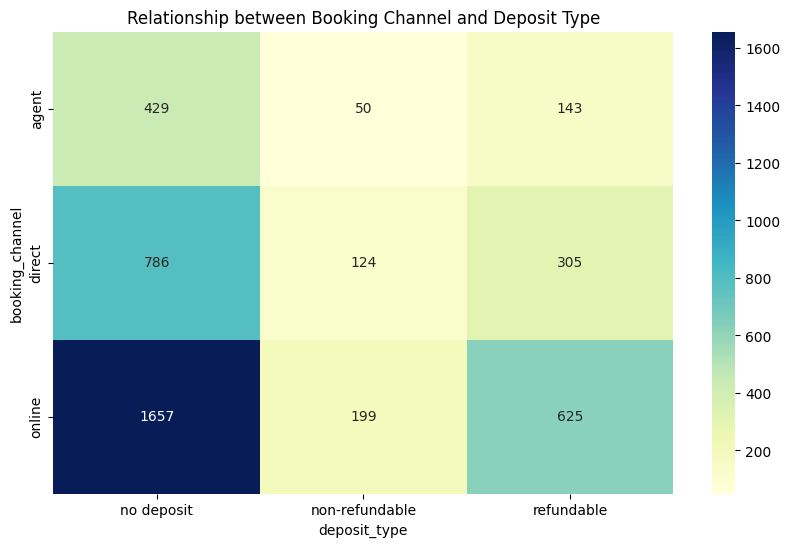

In [37]:
#testing Realationship between channel and depposit type
pivot_table = pd.crosstab(df['booking_channel'], df['deposit_type'])

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Relationship between Booking Channel and Deposit Type')
plt.show()